# Skip-gram with Negative Sampling (SGNS)
A from-scratch implementation of Word2Vec’s SGNS algorithm using only Python and NumPy, without any deep learning frameworks. The notebook covers the main steps of the process, including preprocessing, vocabulary building, subsampling, negative sampling, the forward and backward passes, training, evaluation of the learned word embeddings, and visualization of the learned embeddings using PCA.

## Define Corpus

In [39]:
import random
random.seed(7)

LEXICON = {
    "male_job":    ["doctor", "engineer", "pilot", "chef"],
    "female_job":  ["doctor", "engineer", "pilot", "chef"],
    "workplace":   ["hospital", "factory", "airport", "kitchen"],
    "city":        ["mumbai", "london", "cairo", "seoul"],
    "landmark":    ["gateway", "bigben", "pyramids", "palace"],
    "sport":       ["cricket", "football", "tennis", "badminton"],
    "equipment":   ["bat", "ball", "racket", "shuttle"],
    "vehicle":     ["car", "bicycle", "train", "airplane"],
    "verb_work":   ["worked", "trained", "practiced", "studied"],
    "verb_travel": ["drove", "rode", "flew", "boarded"],
}

CITY_LANDMARK = list(zip(LEXICON["city"], LEXICON["landmark"]))
JOB_WORKPLACE = list(zip(LEXICON["male_job"], LEXICON["workplace"]))
SPORT_EQUIP   = list(zip(LEXICON["sport"], LEXICON["equipment"]))

TEMPLATES = [
    "the {job} {verb_work} at the {workplace} every day",
    "a skilled {job} arrived early at the {workplace}",
    "tourists visited the {landmark} near {city}",
    "the {city} is famous for the {landmark}",
    "she {verb_travel} to {city} to see the {landmark}",
    "he {verb_travel} by {vehicle} to reach the {workplace}",
    "the team {verb_work} hard before the {sport} match",
    "players used a {equipment} during the {sport} game",
    "the {job} enjoys watching {sport} on weekends",
    "the {vehicle} was parked outside the {workplace}",
]

lines = []
for _ in range(3000):
    template = random.choice(TEMPLATES)
    slots = {}
    if "{job}" in template or "{workplace}" in template:
        job, workplace = random.choice(JOB_WORKPLACE)
        slots["job"], slots["workplace"] = job, workplace
    if "{city}" in template or "{landmark}" in template:
        city, landmark = random.choice(CITY_LANDMARK)
        slots["city"], slots["landmark"] = city, landmark
    if "{sport}" in template or "{equipment}" in template:
        sport, equip = random.choice(SPORT_EQUIP)
        slots["sport"], slots["equipment"] = sport, equip
    if "{vehicle}" in template:
        slots["vehicle"] = random.choice(LEXICON["vehicle"])
    if "{verb_work}" in template:
        slots["verb_work"] = random.choice(LEXICON["verb_work"])
    if "{verb_travel}" in template:
        slots["verb_travel"] = random.choice(LEXICON["verb_travel"])
    lines.append(template.format(**slots))

corpus = ". ".join(lines) + "."
print("Corpus:",corpus[:500])
print("\nTotal characters:", len(corpus))

Corpus: he drove by airplane to reach the factory. a skilled doctor arrived early at the hospital. he drove by bicycle to reach the hospital. a skilled chef arrived early at the kitchen. the team trained hard before the cricket match. a skilled chef arrived early at the kitchen. the doctor trained at the hospital every day. the airplane was parked outside the hospital. the engineer worked at the factory every day. the engineer enjoys watching tennis on weekends. the team worked hard before the football 

Total characters: 131299


## Preprocessing

In [40]:
import re

# Split into sentences
sentences = re.split(r'[.!?]+', corpus)
sentences = [s.strip() for s in sentences if s.strip()]

# Tokenize each sentence
tokenized_sentences = []
for s in sentences:
    s = s.lower()
    s = re.sub(r"[^a-z0-9'\s]", "", s)
    tokens = s.split()
    tokenized_sentences.append(tokens)

print("Total sentences:", len(tokenized_sentences))
print("Total tokens:", sum(len(t) for t in tokenized_sentences))

for i, t in enumerate(tokenized_sentences[:10]):
    print(i, t)

Total sentences: 3000
Total tokens: 22490
0 ['he', 'drove', 'by', 'airplane', 'to', 'reach', 'the', 'factory']
1 ['a', 'skilled', 'doctor', 'arrived', 'early', 'at', 'the', 'hospital']
2 ['he', 'drove', 'by', 'bicycle', 'to', 'reach', 'the', 'hospital']
3 ['a', 'skilled', 'chef', 'arrived', 'early', 'at', 'the', 'kitchen']
4 ['the', 'team', 'trained', 'hard', 'before', 'the', 'cricket', 'match']
5 ['a', 'skilled', 'chef', 'arrived', 'early', 'at', 'the', 'kitchen']
6 ['the', 'doctor', 'trained', 'at', 'the', 'hospital', 'every', 'day']
7 ['the', 'airplane', 'was', 'parked', 'outside', 'the', 'hospital']
8 ['the', 'engineer', 'worked', 'at', 'the', 'factory', 'every', 'day']
9 ['the', 'engineer', 'enjoys', 'watching', 'tennis', 'on', 'weekends']


## Vocabulary Building

In [41]:
from collections import Counter

word_counts_full = Counter()
for sentence in tokenized_sentences:
    word_counts_full.update(sentence)

min_count = 2
word_counts = Counter({w: c for w, c in word_counts_full.items() if c >= min_count})

vocab = sorted(word_counts.keys())
vocab_size = len(vocab)

word_2_idx = {}
idx_2_word = {}
for i, word in enumerate(vocab):
    word_2_idx[word] = i
    idx_2_word[i] = word

print("vocab size before cutoff:", len(word_counts_full))
print("vocab size after cutoff :", vocab_size)

vocab size before cutoff: 71
vocab size after cutoff : 71


## Subsampling of Frequent Words

In [42]:
import numpy as np

threshold = 1e-3
total_word_count = sum(word_counts.values())

keep_prob = np.zeros(vocab_size)
for word, idx in word_2_idx.items():
    f = word_counts[word] / total_word_count
    keep_prob[idx] = min(1.0, (np.sqrt(f / threshold) + 1) * (threshold / f))

print("Total word count:", total_word_count)
print("Subsampling threshold:", threshold)

sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
print("\nMost frequent words:")
for word, count in sorted_words[:5]:
    print(f"  {word:12s} count={count:3d}  keep_prob={keep_prob[word_2_idx[word]]:.3f}")

print("\nLeast frequent words:")
for word, count in sorted_words[-5:]:
    print(f"  {word:12s} count={count:3d}  keep_prob={keep_prob[word_2_idx[word]]:.3f}")

Total word count: 22490
Subsampling threshold: 0.001

Most frequent words:
  the          count=4167  keep_prob=0.079
  to           count=907  keep_prob=0.182
  at           count=611  keep_prob=0.229
  a            count=607  keep_prob=0.230
  airport      count=317  keep_prob=0.337

Least frequent words:
  train        count=135  keep_prob=0.575
  ball         count= 79  keep_prob=0.818
  shuttle      count= 76  keep_prob=0.840
  racket       count= 69  keep_prob=0.897
  bat          count= 67  keep_prob=0.915


## Training Pair Generation

In [43]:
pair_rng = np.random.default_rng(42)

window_size = 4

def generate_training_pairs():

    generated_pairs = []

    for sentence in tokenized_sentences:
        ids = []
        for word in sentence:
            if word not in word_2_idx:
                continue

            idx = word_2_idx[word]
            if pair_rng.random() > keep_prob[idx]:
                continue
            ids.append(idx)

        n = len(ids)
        for center_pos in range(n):
            b = pair_rng.integers(1, window_size + 1)
            start = max(0, center_pos - b)
            end = min(n, center_pos + b + 1)

            for context_pos in range(start, end):
                if context_pos != center_pos:
                    generated_pairs.append((ids[center_pos], ids[context_pos]))

    return generated_pairs

pairs = generate_training_pairs()

print("Total training pairs:", len(pairs))
for c, ctx in pairs[:10]:
    print(f"  ({idx_2_word[c]}, {idx_2_word[ctx]})")


Total training pairs: 12799
  (drove, to)
  (to, drove)
  (skilled, chef)
  (chef, skilled)
  (team, trained)
  (team, hard)
  (trained, team)
  (trained, hard)
  (hard, team)
  (hard, trained)


## Negative Sampling Distribution

In [44]:
power = 0.75

freqs = np.zeros(vocab_size)
for word, idx in word_2_idx.items():
    freqs[idx] = word_counts[word]

weighted = freqs ** power
unigram_probs = weighted / weighted.sum()

table_size = 1_000_000
counts = np.maximum(np.round(unigram_probs * table_size).astype(np.int64), 1)
neg_sampling_table = np.repeat(np.arange(vocab_size), counts)

print("Negative table size:", neg_sampling_table.size)
print("Sample of first 20 entries in the table:")
print([idx_2_word[i] for i in neg_sampling_table[:20]])

Negative table size: 999998
Sample of first 20 entries in the table:
['a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a']


## Parameter Initialization

In [45]:
embedding_dim = 50
rng = np.random.RandomState(42)

W_center = (rng.rand(vocab_size, embedding_dim) - 0.5) / embedding_dim
W_context = np.zeros((vocab_size, embedding_dim))

print("W_center shape:", W_center.shape)
print("W_context shape:", W_context.shape)
print("Sample rows of W_center (first 2 words):")
print(W_center[:2])

W_center shape: (71, 50)
W_context shape: (71, 50)
Sample rows of W_center (first 2 words):
[[-2.50919762e-03  9.01428613e-03  4.63987884e-03  1.97316968e-03
  -6.87962719e-03 -6.88010959e-03 -8.83832776e-03  7.32352292e-03
   2.02230023e-03  4.16145156e-03 -9.58831011e-03  9.39819704e-03
   6.64885282e-03 -5.75321779e-03 -6.36350066e-03 -6.33190980e-03
  -3.91515514e-03  4.95128633e-04 -1.36109963e-03 -4.17541720e-03
   2.23705789e-03 -7.21012279e-03 -4.15710703e-03 -2.67276313e-03
  -8.78600316e-04  5.70351923e-03 -6.00652436e-03  2.84688768e-04
   1.84829138e-03 -9.07099175e-03  2.15089704e-03 -6.58951753e-03
  -8.69896814e-03  8.97771075e-03  9.31264066e-03  6.16794696e-03
  -3.90772462e-03 -8.04655772e-03  3.68466053e-03 -1.19695013e-03
  -7.55923530e-03 -9.64617978e-05 -9.31222958e-03  8.18640804e-03
  -4.82440037e-03  3.25044569e-03 -3.76577848e-03  4.01360424e-04
   9.34205587e-04 -6.30291089e-03]
 [ 9.39169256e-03  5.50265647e-03  8.78997883e-03  7.89654701e-03
   1.95799958e-

## Forward Pass


In [46]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

k = 5
demo_rng = np.random.RandomState(1)

center_idx, context_idx = pairs[0]

neg_indices = neg_sampling_table[demo_rng.randint(0, table_size, size=k)]

v_center = W_center[center_idx]
v_context = W_context[context_idx]
v_negs = W_context[neg_indices]

pos_score = sigmoid(np.dot(v_center, v_context))
neg_scores = sigmoid(-np.dot(v_negs, v_center))

loss = -np.log(pos_score + 1e-10) - np.sum(np.log(neg_scores + 1e-10))

print("Center, context pair:", idx_2_word[center_idx], idx_2_word[context_idx])
print("Negative samples:", [idx_2_word[i] for i in neg_indices])
print("Positive score:", pos_score)
print("Negative scores:", neg_scores)
print("Loss:", loss)

Center, context pair: drove to
Negative samples: ['bicycle', 'match', 'kitchen', 'the', 'match']
Positive score: 0.5
Negative scores: [0.5 0.5 0.5 0.5 0.5]
Loss: 4.158883082159671


## Backward Pass

In [47]:
learning_rate = 0.05

z_pos = np.dot(v_center, v_context)
z_neg = np.dot(v_negs, v_center)

g_pos = sigmoid(z_pos) - 1
g_neg = sigmoid(z_neg)

grad_context = g_pos * v_center
grad_negs = np.outer(g_neg, v_center)
grad_center = g_pos * v_context + np.dot(g_neg, v_negs)

W_context[context_idx] -= learning_rate * grad_context
np.add.at(W_context, neg_indices, -learning_rate * grad_negs)
W_center[center_idx] -= learning_rate * grad_center

print("Gradient w.r.t. center vector:", grad_center)
print("Gradient w.r.t. context vector:", grad_context)
print("Gradient w.r.t. negative vectors:", grad_negs)

Gradient w.r.t. center vector: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Gradient w.r.t. context vector: [-1.00516860e-03 -1.65036675e-03  3.24628721e-03 -4.14411946e-03
  8.12294751e-04  1.16861472e-03 -1.89177053e-04  4.53034033e-03
  3.33716631e-03 -2.38033616e-03  4.17201332e-03 -1.03152109e-03
  2.54650890e-03  1.10704386e-03  2.11306263e-03  1.44327284e-03
 -2.19045905e-03  2.02878284e-03 -6.64046403e-04  2.39495978e-04
 -1.63671165e-03 -4.36829739e-03 -2.32572097e-03  2.85059621e-03
  4.68816865e-03  2.37735956e-03 -9.50779307e-04  4.48574187e-03
  3.63375280e-05 -9.68428489e-04  1.65756109e-03 -2.70912204e-03
  3.93401747e-03  4.24862218e-03 -2.28188756e-03  4.50868379e-05
 -1.88402396e-03  6.51726614e-04  2.53597967e-03 -3.19102318e-03
 -2.99415879e-03 -1.94696471e-03  2.27854863e-03 -9.02306669e-04
  1.39026103e-03  4.08417927e-03 -4.17313575e-03  3.63181369e-03
 -4

## Training Loop

In [48]:
epochs = 30
k = 5
initial_lr = 0.05
final_lr = 0.0005
train_rng = np.random.default_rng(7)

loss_history = []

for epoch in range(epochs):
    if epochs > 1:
        lr = initial_lr + (final_lr - initial_lr) * (epoch / (epochs - 1))
    else:
        lr = initial_lr


    pairs = generate_training_pairs()
    train_rng.shuffle(pairs)

    total_loss = 0.0

    for center_idx, context_idx in pairs:
        neg_indices = neg_sampling_table[
            train_rng.integers(0, neg_sampling_table.size, size=k)
        ]

        clash = neg_indices == context_idx
        while clash.any():
            neg_indices[clash] = neg_sampling_table[
                train_rng.integers(0, neg_sampling_table.size, size=clash.sum())
            ]
            clash = neg_indices == context_idx

        v_center = W_center[center_idx]
        v_context = W_context[context_idx]
        v_negs = W_context[neg_indices]

        z_pos = np.dot(v_center, v_context)
        z_neg = np.dot(v_negs, v_center)

        pos_score = sigmoid(z_pos)
        neg_scores = sigmoid(-z_neg)

        example_loss = (
            -np.log(pos_score + 1e-10)
            - np.sum(np.log(neg_scores + 1e-10))
        )
        total_loss += example_loss

        g_pos = pos_score - 1.0
        g_neg = sigmoid(z_neg)

        grad_context = g_pos * v_center
        grad_negs = np.outer(g_neg, v_center)
        grad_center = g_pos * v_context + np.dot(g_neg, v_negs)

        W_context[context_idx] -= lr * grad_context


        np.add.at(W_context, neg_indices, -lr * grad_negs)

        W_center[center_idx] -= lr * grad_center

    avg_loss = total_loss / max(len(pairs), 1)
    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"pairs={len(pairs):6d} | lr={lr:.5f} | avg loss={avg_loss:.4f}"
    )


Epoch 01/30 | pairs= 12126 | lr=0.05000 | avg loss=3.0191
Epoch 02/30 | pairs= 12523 | lr=0.04829 | avg loss=1.9347
Epoch 03/30 | pairs= 12473 | lr=0.04659 | avg loss=1.7378
Epoch 04/30 | pairs= 12557 | lr=0.04488 | avg loss=1.7005
Epoch 05/30 | pairs= 12469 | lr=0.04317 | avg loss=1.6713
Epoch 06/30 | pairs= 12672 | lr=0.04147 | avg loss=1.6395
Epoch 07/30 | pairs= 12702 | lr=0.03976 | avg loss=1.6092
Epoch 08/30 | pairs= 12396 | lr=0.03805 | avg loss=1.6012
Epoch 09/30 | pairs= 12459 | lr=0.03634 | avg loss=1.5971
Epoch 10/30 | pairs= 12435 | lr=0.03464 | avg loss=1.5425
Epoch 11/30 | pairs= 12784 | lr=0.03293 | avg loss=1.5637
Epoch 12/30 | pairs= 12479 | lr=0.03122 | avg loss=1.5617
Epoch 13/30 | pairs= 12874 | lr=0.02952 | avg loss=1.5706
Epoch 14/30 | pairs= 12427 | lr=0.02781 | avg loss=1.5284
Epoch 15/30 | pairs= 12579 | lr=0.02610 | avg loss=1.5501
Epoch 16/30 | pairs= 12591 | lr=0.02440 | avg loss=1.5306
Epoch 17/30 | pairs= 12810 | lr=0.02269 | avg loss=1.5151
Epoch 18/30 | 

## Evaluation & Inspection of Embeddings

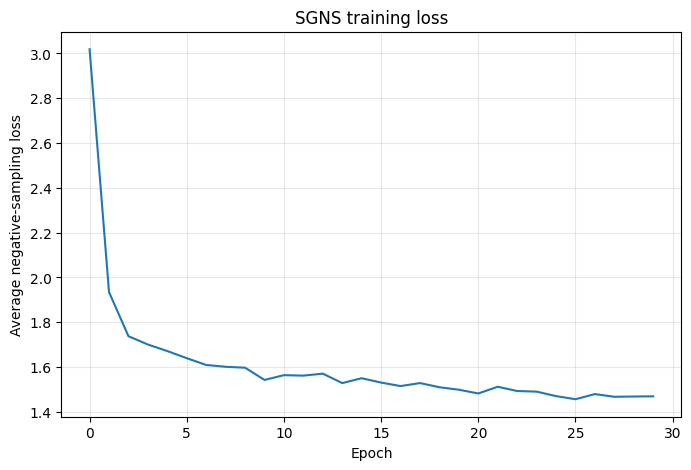

Nearest neighbours:
  doctor: [('at', np.float64(0.6308495684148664)), ('chef', np.float64(0.5975643495315568)), ('arrived', np.float64(0.5850971014959587)), ('early', np.float64(0.5816091683822328)), ('skilled', np.float64(0.5794422866761404))]
  engineer: [('at', np.float64(0.6374037963996257)), ('chef', np.float64(0.5920450424454174)), ('pilot', np.float64(0.5841126582856666)), ('every', np.float64(0.5762971116920761)), ('doctor', np.float64(0.5728283979215454))]
  cricket: [('tennis', np.float64(0.6736602508955812)), ('bat', np.float64(0.6614070525409336)), ('badminton', np.float64(0.6301921207513447)), ('football', np.float64(0.6206723187957327)), ('hard', np.float64(0.6160238074879971))]
  mumbai: [('gateway', np.float64(0.9965608901569613)), ('see', np.float64(0.6757563978405797)), ('she', np.float64(0.6697045423205682)), ('famous', np.float64(0.6041228641497006)), ('is', np.float64(0.6032460261966028))]

Analogies:
  doctor:hospital :: chef:?  -> [('kitchen', np.float64(0.98295

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average negative-sampling loss")
plt.title("SGNS training loss")
plt.grid(alpha=0.3)
plt.show()


W = W_center + W_context


def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)


def most_similar(word, top_n=5):
    if word not in word_2_idx:
        return []

    query_idx = word_2_idx[word]
    query_vec = W[query_idx]

    sims = [
        (idx_2_word[i], cosine_sim(query_vec, W[i]))
        for i in range(vocab_size)
        if i != query_idx
    ]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_n]


def analogy(a, b, c, top_n=5):
    if not all(w in word_2_idx for w in (a, b, c)):
        return []

    target = W[word_2_idx[b]] - W[word_2_idx[a]] + W[word_2_idx[c]]

    excluded = {a, b, c}
    sims = [
        (idx_2_word[i], cosine_sim(target, W[i]))
        for i in range(vocab_size)
        if idx_2_word[i] not in excluded
    ]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_n]


print("Nearest neighbours:")
for word in ["doctor", "engineer", "cricket", "mumbai", "computer"]:
    if word in word_2_idx:
        print(f"  {word}: {most_similar(word)}")


print("\nAnalogies:")
tests = [
    ("doctor", "hospital", "chef"),
    ("mumbai", "gateway", "london"),
    ("cricket", "bat", "tennis"),
]

for a, b, c in tests:
    if all(w in word_2_idx for w in (a, b, c)):
        print(f"  {a}:{b} :: {c}:?  -> {analogy(a, b, c)}")



relation_tests = [
    ("doctor", "hospital"),
    ("engineer", "factory"),
    ("pilot", "airport"),
    ("chef", "kitchen"),
    ("cricket", "bat"),
    ("football", "ball"),
    ("tennis", "racket"),
    ("badminton", "shuttle"),
    ("mumbai", "gateway"),
    ("london", "bigben"),
    ("cairo", "pyramids"),
    ("seoul", "palace"),
]

relation_scores = []
for a, b in relation_tests:
    if a in word_2_idx and b in word_2_idx:
        relation_scores.append((a, b, cosine_sim(W[word_2_idx[a]], W[word_2_idx[b]])))

relation_scores.sort(key=lambda x: x[2], reverse=True)

print("\nKnown co-occurrence relationships (cosine similarity):")
for a, b, score in relation_scores:
    print(f"  {a:10s} - {b:10s}: {score:.4f}")

if relation_scores:
    print(
        f"\nMean similarity across {len(relation_scores)} known relationships: "
        f"{np.mean([x[2] for x in relation_scores]):.4f}"
    )


## Visualizing the Embedding Space with PCA

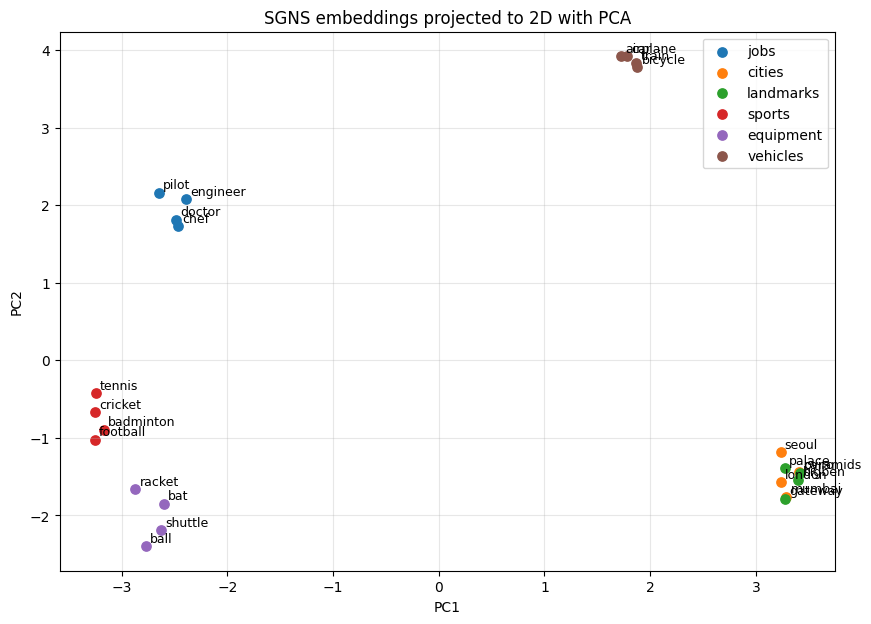

In [50]:
def pca_2d(X):
    X_centered = X - X.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ Vt[:2].T

groups = {
    "jobs":      [w for w in ["doctor", "engineer", "pilot", "chef"] if w in word_2_idx],
    "cities":    [w for w in ["mumbai", "london", "cairo", "seoul"] if w in word_2_idx],
    "landmarks": [w for w in ["gateway", "bigben", "pyramids", "palace"] if w in word_2_idx],
    "sports":    [w for w in ["cricket", "football", "tennis", "badminton"] if w in word_2_idx],
    "equipment": [w for w in ["bat", "ball", "racket", "shuttle"] if w in word_2_idx],
    "vehicles":  [w for w in ["car", "bicycle", "train", "airplane"] if w in word_2_idx],
}

words = [w for g in groups.values() for w in g]
coords = pca_2d(W[[word_2_idx[w] for w in words]])

plt.figure(figsize=(10, 7))
start = 0
for name, g in groups.items():
    xs = coords[start:start + len(g), 0]
    ys = coords[start:start + len(g), 1]
    plt.scatter(xs, ys, label=name, s=45)
    for w, x, y in zip(g, xs, ys):
        plt.annotate(w, (x, y), fontsize=9, xytext=(3, 3), textcoords="offset points")
    start += len(g)

plt.legend()
plt.title("SGNS embeddings projected to 2D with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

## Summary

This notebook implements Skip-gram with Negative Sampling (SGNS) from scratch using Python and NumPy. It covers corpus generation and preprocessing, vocabulary creation, subsampling, context-window sampling, negative sampling, the SGNS objective, gradient calculation, training, and embedding evaluation.

The experiment was improved by using a larger synthetic corpus, dynamic context windows, and new training pairs for each epoch. The learning rate is also gradually reduced during training.

The learned embeddings are evaluated using nearest neighbours, word analogies, cosine similarity, and PCA visualization. These evaluations help show whether the model is able to learn meaningful relationships between words.

Since the corpus is synthetic and relatively small, the results are not expected to match embeddings trained on large real-world datasets. The main goal is to demonstrate how SGNS works and show how word relationships can be learned from word co-occurrence.

Overall, the notebook demonstrates the complete SGNS pipeline, from data preparation and training to embedding evaluation.
